In [30]:
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from scipy import stats
import numpy as np
import pandas as pd, numpy as np
from ast import literal_eval
from collections import defaultdict
from scipy.stats import fisher_exact, false_discovery_control
import pandas as pd, numpy as np
from scipy.stats import fisher_exact, mannwhitneyu, false_discovery_control
from scipy import stats

In [31]:
adata = sc.read_h5ad("/rds/general/user/ao225/home/CardiaFinal/Data/Post_Processed/Science/NewCardiac.h5ad")

In [32]:
auc_df = pd.DataFrame(adata.obsm["AUCell"], columns=adata.uns["regulons"], index=adata.obs_names)
pb = auc_df.groupby([adata.obs["donor_id"].values, adata.obs["disease"].values],
                    observed=True).mean()
pb.index.names = ["donor", "disease"]
print(pb.shape)                                              
print(pb.index.get_level_values("disease").value_counts())  # 42 DCM, 12 normal

dcm = pb.xs("dilated cardiomyopathy", level="disease")
nor = pb.xs("normal", level="disease")

res = [mannwhitneyu(dcm[c], nor[c], alternative="two-sided") for c in pb.columns]
u = [r.statistic for r in res]
p = [r.pvalue for r in res]

out = pd.DataFrame({
    "regulon":     pb.columns,
    "mean_DCM":    dcm.mean(0).values,
    "mean_normal": nor.mean(0).values,
    "delta_AUC":   (dcm.mean(0) - nor.mean(0)).values,
    "pct_change":  (100 * (dcm.mean(0) - nor.mean(0)) / nor.mean(0)).values,
    "U": u, "pval": p,
})
out["padj"] = stats.false_discovery_control(out["pval"])
out = out.sort_values("padj")
out["significant"] = out["padj"] < 0.05
out["n_targets"] = out["regulon"].map(lambda t: len(regulons.get(t, set())))
print(out.head(20).to_string(index=False))
print((out["padj"] < 0.05).sum())

(50, 72)
disease
dilated cardiomyopathy    38
normal                    12
Name: count, dtype: int64
regulon  mean_DCM  mean_normal  delta_AUC  pct_change     U     pval     padj  significant  n_targets
ZNF518A  0.100160     0.086050   0.014110   16.397534 414.0 0.000025 0.000904         True         82
 ZNF431  0.034085     0.044351  -0.010265  -23.145862  41.0 0.000023 0.000904         True         26
  ZNF43  0.042559     0.058504  -0.015945  -27.255057  53.0 0.000074 0.000973         True         15
  IKZF2  0.182477     0.167256   0.015221    9.100462 402.0 0.000081 0.000973         True         90
 ZBTB16  0.352644     0.245693   0.106951   43.530217 405.0 0.000061 0.000973         True         10
  FOXO1  0.109664     0.092825   0.016838   18.139751 406.0 0.000055 0.000973         True        455
   KLF9  0.164540     0.130204   0.034336   26.371019 393.0 0.000186 0.001918         True        101
  FOXO3  0.129212     0.111546   0.017666   15.837608 382.0 0.000489 0.004167      

In [40]:
out.to_csv("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/Table/Supplementary_regulon_activity.csv", index=False)

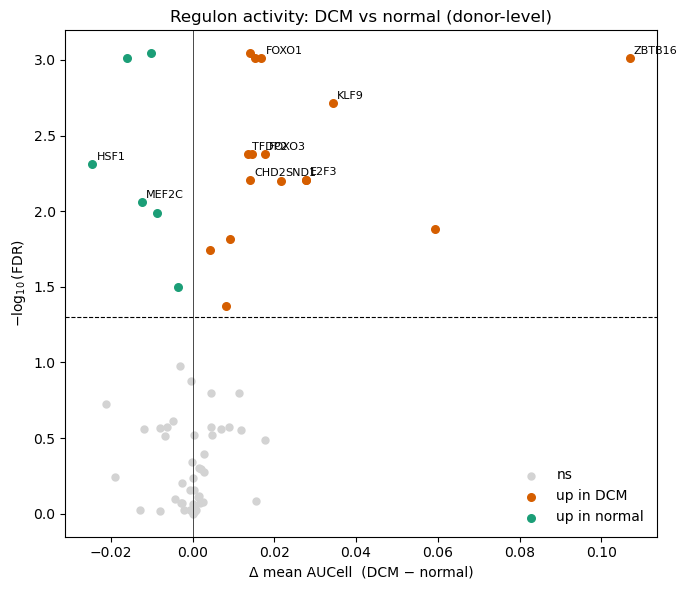

In [33]:
out["neglog10_padj"] = -np.log10(out["padj"])
sig = out["padj"] < 0.05

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(out.loc[~sig, "delta_AUC"], out.loc[~sig, "neglog10_padj"],
           c="lightgray", s=25, label="ns")
ax.scatter(out.loc[sig & (out.delta_AUC > 0), "delta_AUC"],
           out.loc[sig & (out.delta_AUC > 0), "neglog10_padj"],
           c="#D55E00", s=30, label="up in DCM")
ax.scatter(out.loc[sig & (out.delta_AUC < 0), "delta_AUC"],
           out.loc[sig & (out.delta_AUC < 0), "neglog10_padj"],
           c="#1B9E77", s=30, label="up in normal")

label_these = ["KLF9","FOXO1","FOXO3","MEF2C","TFDP2","CHD2","SND1","HSF1","ZBTB16","E2F3"]
top = out[out.regulon.isin(label_these)]
for _, r in top.iterrows():
    ax.annotate(r["regulon"], (r["delta_AUC"], r["neglog10_padj"]),
                fontsize=8, xytext=(3, 3), textcoords="offset points")

ax.axhline(-np.log10(0.05), ls="--", c="k", lw=0.8)
ax.axvline(0, ls="-", c="k", lw=0.5)
ax.set_xlabel("Δ mean AUCell  (DCM − normal)")
ax.set_ylabel(r"$-\log_{10}$(FDR)")
ax.set_title("Regulon activity: DCM vs normal (donor-level)")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/plots/volcano_regulons_DCM_vs_normal.png", dpi=300)
plt.show()

In [34]:
import pandas as pd, numpy as np
from ast import literal_eval
from collections import defaultdict
from scipy.stats import fisher_exact, false_discovery_control

# 1. regulon -> target symbols (pySCENIC motifs)
mot = pd.read_csv("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/SCENIC_results/lv_regulons.motifs.csv",
                  header=[0,1], index_col=[0,1], skipinitialspace=True)
regulons = defaultdict(set)
for (tf, _), s in mot[('Enrichment','TargetGenes')].items():
    for g, w in literal_eval(s):
        regulons[tf].add(g)

# 2. ENSG -> symbol map from adata
ens2sym = adata.var["feature_name"].astype(str).to_dict()

# 3. load ds lists, map ENSG -> symbol
base = "/rds/general/user/ao225/home/CardiaFinal/Results/ROGUE/gene_set"
files = {g: f"{base}/ds_{g}.txt" for g in ["control","chromatin","sarcomere","splicing","PVneg"]}
ds = {}
for name, f in files.items():
    ens = pd.read_csv(f, header=None)[0].astype(str).tolist()
    ds[name] = {ens2sym.get(e) for e in ens} - {None}
    print(name, len(ens), "->", len(ds[name]), "symbols")

# DCM-specific ds genes: significant in any DCM genotype, not in control
dcm_ds = (ds["chromatin"] | ds["sarcomere"] | ds["splicing"] | ds["PVneg"]) - ds["control"]
print("DCM-specific ds genes:", len(dcm_ds))

# 4. UNIVERSE = SE_fun-tested genes (refset), mapped to symbols
refset_ens = pd.read_csv(f"{base}/refset.txt", header=None)[0].astype(str).tolist()
universe = {ens2sym.get(e) for e in refset_ens} - {None}
print("universe size:", len(universe))

# keep everything inside the universe
dcm_ds &= universe
N, K = len(universe), len(dcm_ds)

# 5. Fisher enrichment per activity-significant regulon
sig_regs = out.loc[out["padj"] < 0.05, "regulon"].tolist()
rows = []
for tf in sig_regs:
    targ = regulons.get(tf, set()) & universe          # only targets that were testable
    if len(targ) < 5:
        continue
    a = len(targ & dcm_ds); b = len(targ) - a
    c = K - a;              d = N - len(targ) - c
    odds, p = fisher_exact([[a, b], [c, d]], alternative="greater")
    rows.append({"regulon": tf, "n_targets": len(targ), "targets_ds": a,
                 "expected": round(len(targ)*K/N, 1),
                 "odds_ratio": round(odds, 2), "pval": p})

val = pd.DataFrame(rows)
val["padj"] = false_discovery_control(val["pval"])
val = val.merge(out[["regulon","delta_AUC","pct_change"]], on="regulon").sort_values("pval")
val["interpretable"] = val["n_targets"] >= 50
val.to_csv("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/Table/Supplementary_regulon_entropy_enrichment.csv", index=False)
print(val.to_string(index=False))

control 143 -> 143 symbols
chromatin 243 -> 243 symbols
sarcomere 197 -> 197 symbols
splicing 171 -> 171 symbols
PVneg 193 -> 193 symbols
DCM-specific ds genes: 217
universe size: 20606
regulon  n_targets  targets_ds  expected  odds_ratio         pval         padj  delta_AUC  pct_change  interpretable
   KLF9        101          17       1.1       20.55 4.697256e-16 1.033396e-14   0.034336   26.371019           True
  FOXO3        518          30       5.5        6.54 3.275726e-14 3.603299e-13   0.017666   15.837608           True
  FOXO1        455          26       4.8        6.33 2.602343e-12 1.908385e-11   0.016838   18.139751           True
 ZNF407        648          27       6.8        4.52 1.204120e-09 6.622659e-09   0.008146    6.402790           True
  TFDP2        660          26       7.0        4.24 7.975658e-09 3.509290e-08   0.013579   11.124215           True
 ZBTB16         10           4       0.1       63.80 2.390625e-06 8.765624e-06   0.106951   43.530217          F

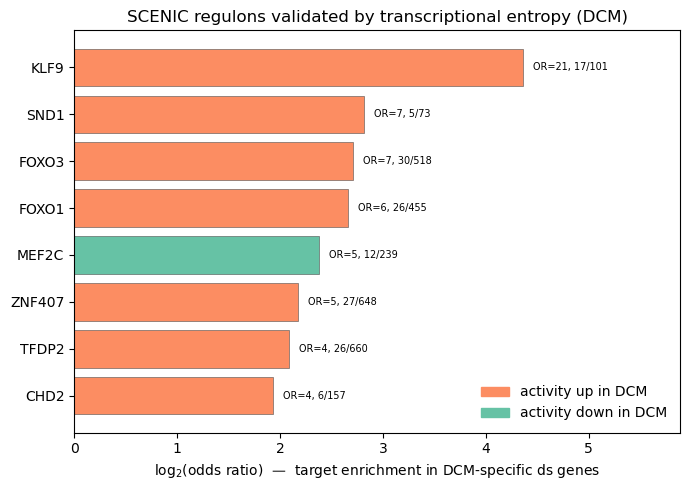

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

v = val[(val["padj"] < 0.05) & (val["interpretable"])].copy().sort_values("odds_ratio")
v["neglog10"] = -np.log10(v["padj"])
colors = np.where(v["delta_AUC"] > 0, "#FC8D62", "#66C2A5")

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(v["regulon"], np.log2(v["odds_ratio"]), color=colors,
        edgecolor="0.3", linewidth=.4)

for y, (_, r) in enumerate(v.iterrows()):
    ax.text(np.log2(r["odds_ratio"]) + 0.1, y,
            f"OR={r['odds_ratio']:.0f}, {r['targets_ds']}/{r['n_targets']}",
            va="center", fontsize=7)

ax.set_xlim(0, np.log2(v["odds_ratio"].max()) * 1.35)
ax.set_xlabel("log$_2$(odds ratio)  —  target enrichment in DCM-specific ds genes")
ax.set_title("SCENIC regulons validated by transcriptional entropy (DCM)")
ax.legend(handles=[Patch(color="#FC8D62", label="activity up in DCM"),
                   Patch(color="#66C2A5", label="activity down in DCM")],
          frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/plots/regulon_entropy_validation.png", dpi=300)
plt.show()

In [41]:
import pandas as pd, numpy as np
from scipy.stats import mannwhitneyu, false_discovery_control

d = "/rds/general/user/ao225/home/CardiaFinal/Results/ROGUE/per_gene"
dcm_groups = ["chromatin","sarcomere","splicing","PVneg"]
load = lambda g: pd.read_csv(f"{d}/ds_{g}.csv").set_index("Gene")["ds"]

# ds per gene: mean across DCM groups, and control
dcm_mean = pd.concat([load(g) for g in dcm_groups], axis=1).mean(axis=1)   # ignores NaN
ctrl     = load("control")

# Δds = DCM - control, only genes tested in control AND ≥1 DCM group
delta = (dcm_mean - ctrl).dropna()

# ENSG -> symbol, collapse duplicates
delta.index = delta.index.map(lambda e: ens2sym.get(e))
delta = delta[delta.index.notna()].groupby(level=0).mean()
universe = set(delta.index)
print("genes with Δds:", len(universe))

# one-sided: do a regulon's targets have HIGHER Δds (more DCM-specific disorder) than the rest?
sig_regs = out.loc[out["padj"] < 0.05, "regulon"].tolist()
rows = []
for tf in sig_regs:
    targ = regulons.get(tf, set()) & universe
    if len(targ) < 5: continue
    inn = delta[delta.index.isin(targ)]
    bg  = delta[~delta.index.isin(targ)]
    U, p = mannwhitneyu(inn, bg, alternative="greater")
    rows.append({"regulon": tf, "n_targets": len(targ),
                 "median_dds_target": round(inn.median(), 5),
                 "median_dds_bg": round(bg.median(), 5),
                 "U": U, "pval": p})

r = pd.DataFrame(rows)
r["padj"] = false_discovery_control(r["pval"])
r = r.merge(out[["regulon","delta_AUC","pct_change"]], on="regulon").sort_values("pval")
r["interpretable"] = r["n_targets"] >= 50
r.to_csv("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/Table/Supplementary_regulon_delta_ds.csv", index=False)
print(r.to_string(index=False))

genes with Δds: 19304
regulon  n_targets  median_dds_target  median_dds_bg         U         pval         padj  delta_AUC  pct_change  interpretable
 ZNF407        648            0.00077       -0.00004 7222662.0 1.483244e-17 3.263138e-16   0.008146    6.402790           True
   KLF9        101            0.00366       -0.00003 1403206.0 4.251386e-15 4.676525e-14   0.034336   26.371019           True
  FOXO1        455            0.00053       -0.00003 5046051.0 5.505594e-11 4.037435e-10   0.016838   18.139751           True
   NFIB         27            0.00386       -0.00003  412669.0 6.906870e-08 3.798779e-07   0.014570   10.885075          False
  FOXO3        518            0.00038       -0.00003 5481493.0 4.269505e-07 1.878582e-06   0.017666   15.837608           True
  MEF2C        239            0.00078       -0.00003 2680292.0 1.329179e-06 4.873657e-06  -0.012399   -8.477131           True
 ZBTB16         10            0.01079       -0.00003  162314.0 9.300496e-05 2.923013e-04 

In [42]:
import pandas as pd, numpy as np
from scipy.stats import fisher_exact, mannwhitneyu, false_discovery_control

gene_set = "/rds/general/user/ao225/home/CardiaFinal/Results/ROGUE/gene_set"
rogue    = "/rds/general/user/ao225/home/CardiaFinal/Results/ROGUE/per_gene"
dcm_groups = ["chromatin","sarcomere","splicing","PVneg"]
sig_regs   = out.loc[out["padj"] < 0.05, "regulon"].tolist()


# universe = SE_fun-tested genes (refset), as symbols
universe = {ens2sym.get(e) for e in pd.read_csv(f"{gene_set}/refset.txt", header=None)[0].astype(str)} - {None}
N = len(universe)

# high-entropy symbol sets per group (reload to be safe)
ds_sets = {}
for g in dcm_groups + ["control"]:
    ens = pd.read_csv(f"{gene_set}/ds_{g}.txt", header=None)[0].astype(str)
    ds_sets[g] = ({ens2sym.get(e) for e in ens} - {None}) & universe

# continuous ds per group
load = lambda g: pd.read_csv(f"{rogue}/ds_{g}.csv").set_index("Gene")["ds"]
ctrl_ds = load("control")

fisher_rows, dds_rows = [], []
for g in dcm_groups:
    # ---- (a) Fisher: group high-entropy (vs control) ----
    hs = he[g] - he["control"]; K = len(hs)
    for tf in sig_regs:
        targ = regulons.get(tf, set()) & universe
        if len(targ) < 5: continue
        a = len(targ & hs); b = len(targ)-a; c = K-a; d = N-len(targ)-c
        odds, p = fisher_exact([[a,b],[c,d]], alternative="greater")
        fisher_rows.append({"regulon":tf,"group":g,"OR":round(odds,1),"pval":p})

    # ---- (b) Δds: this genotype minus control ----
    delta = (load(g) - ctrl_ds).dropna()
    delta.index = delta.index.map(lambda e: ens2sym.get(e))
    delta = delta[delta.index.notna()].groupby(level=0).mean()
    uni = set(delta.index)
    for tf in sig_regs:
        targ = regulons.get(tf, set()) & uni
        if len(targ) < 5: continue
        inn = delta[delta.index.isin(targ)]; bg = delta[~delta.index.isin(targ)]
        U, p = mannwhitneyu(inn, bg, alternative="greater")
        dds_rows.append({"regulon":tf,"group":g,"med_dds":round(inn.median(),4),"pval":p})

fis = pd.DataFrame(fisher_rows); fis["padj"] = fis.groupby("group")["pval"].transform(false_discovery_control)
dds = pd.DataFrame(dds_rows);   dds["padj"] = dds.groupby("group")["pval"].transform(false_discovery_control)

# ---- consensus matrix: regulon validated (BOTH tests padj<0.05) in each genotype ----
pass_f = {(r.regulon, r.group) for r in fis.itertuples() if r.padj < 0.05}
pass_d = {(r.regulon, r.group) for r in dds.itertuples() if r.padj < 0.05}
both = pass_f & pass_d

mat = pd.DataFrame(0, index=sorted({tf for tf,_ in both}), columns=dcm_groups)
for tf, g in both: mat.loc[tf, g] = 1
mat["n_genotypes"] = mat[dcm_groups].sum(axis=1)
mat["n_targets"] = [len(regulons.get(tf, set()) & universe) for tf in mat.index]
mat["interpretable"] = mat["n_targets"] >= 50
print(mat.sort_values(["n_genotypes","n_targets"], ascending=False).to_string())
mat.to_csv("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/Table/Supplementary_regulon_genotype_validation.csv")

        chromatin  sarcomere  splicing  PVneg  n_genotypes  n_targets  interpretable
FOXO3           1          1         1      1            4        518           True
FOXO1           1          1         1      1            4        455           True
KLF9            1          1         1      1            4        101           True
ZNF407          1          0         1      1            3        648           True
ZNF189          1          1         0      1            3         22          False
MEF2C           1          0         0      1            2        239           True
ZBTB16          1          1         0      0            2         10          False
TFDP2           0          0         0      1            1        660           True
CHD2            1          0         0      0            1        157           True
NFIB            1          0         0      0            1         27          False


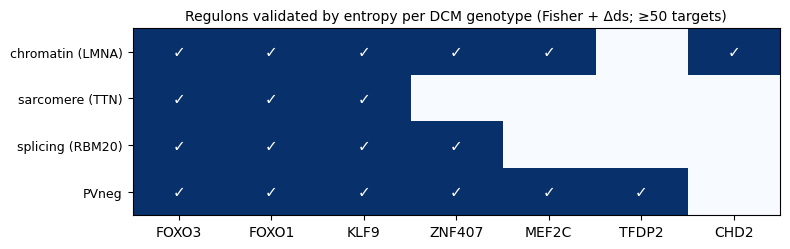

In [43]:
import matplotlib.pyplot as plt
import numpy as np

m_full = mat[mat["interpretable"]].sort_values(["n_genotypes","n_targets"], ascending=False)
m = m_full[dcm_groups].T          # transpose

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.imshow(m.values, cmap="Blues", vmin=0, vmax=1, aspect="auto", interpolation="nearest")
ax.set_xticks(range(len(m.columns))); ax.set_xticklabels(m.columns, fontsize=10)
ax.set_yticks(range(len(dcm_groups)))
ax.set_yticklabels(["chromatin (LMNA)","sarcomere (TTN)","splicing (RBM20)","PVneg"], fontsize=9)

for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        if m.values[i, j]:
            ax.text(j, i, "✓", ha="center", va="center", color="white", fontsize=11)

ax.set_title("Regulons validated by entropy per DCM genotype (Fisher + Δds; ≥50 targets)", fontsize=10)
plt.tight_layout()
plt.savefig("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/plots/regulon_validation_by_genotype.png", dpi=300)
plt.show()

In [20]:
adata.obs.columns

Index(['Sample', 'donor_id', 'Region_x', 'Primary.Genetic.Diagnosis',
       'n_genes', 'n_counts', 'percent_mito', 'percent_ribo',
       'scrublet_score_z', 'scrublet_score_log', 'solo_score', 'cell_states',
       'Assigned', 'self_reported_ethnicity_ontology_term_id',
       'disease_ontology_term_id', 'cell_type_ontology_term_id',
       'sex_ontology_term_id', 'assay_ontology_term_id', 'is_primary_data',
       'tissue_ontology_term_id', 'development_stage_ontology_term_id',
       'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease',
       'sex', 'tissue', 'self_reported_ethnicity', 'development_stage',
       'observation_joinid', 'pathway', 'Genotype'],
      dtype='object')

In [21]:
pathway_map = {
    "LMNA":  "chromatin",
    "TTN":   "sarcomere", "TNNC1": "sarcomere", "TNNT2": "sarcomere",
    "RBM20": "splicing",
    "PVneg": "PVneg",
    "control": "control"
}
adata.obs["pathway"] = adata.obs["Primary.Genetic.Diagnosis"].map(pathway_map)

In [22]:
print(adata.obs["pathway"].value_counts())

pathway
control      39667
chromatin    22186
sarcomere    17965
splicing      6798
PVneg         5340
Name: count, dtype: int64


In [15]:
import scanpy as sc, matplotlib.pyplot as plt

auc_df = pd.DataFrame(adata.obsm["AUCell"], columns=adata.uns["regulons"], index=adata.obs_names)
order = ["control","chromatin","sarcomere","splicing","PVneg"]

reg = "ZNF189"
adata.obs[reg] = auc_df[reg].values
vmax = auc_df[reg].quantile(0.99)

fig, axs = plt.subplots(1, len(order), figsize=(4*len(order), 4))
for ax, g in zip(axs, order):
    sub = adata[adata.obs["pathway"] == g]          # <- singular
    sc.pl.umap(sub, color=reg, vmin=0, vmax=vmax, ax=ax, show=False,
               frameon=False, title=f"{reg} — {g}  (n={sub.n_obs})")
plt.tight_layout(); plt.savefig(f"umap_{reg}_by_pathway.png", dpi=200); plt.close()